## Timing Analysis for the Conv2D accelerator

In this demo, we show how to view the timing progress of the accelerator

## Pre-requisites

Before using this notebook, run:

```bash
python conv2d_demo.py --through generate_vcd --trace_level port [--live_output]
```

With the default `--start_at csim`, this runs the histogram flow through these stages:

- `csim`: C simulation
- `csynth`: C synthesis
- `cosim`: C/RTL co-simulation
- `generate_vcd`: re-run the RTL simulation to write a VCD file

You can also run the stages in smaller pieces. For example:

```bash
python conv2d_demo.py --through csynth [--live_output]
python conv2d_demo.py --start_at cosim --through generate_vcd --trace_level port [--live_output]
```

The first command runs C simulation and C synthesis.
The second command reuses the existing project, starts at RTL co-simulation, and then generates the VCD.

## Parsing the VCD File

We first run the `timing_analysis` function in the project that will extract the AXI bursts from input, output and debug streams. 

In [2]:
from timing_analysis import analyze_vcd
from pathlib import Path
import numpy as np

vcd_path = Path.cwd() / "vcd" / "dump.vcd"
bursts, clk_period = analyze_vcd(vcd_path)

Input bursts: 1
Debug bursts: 102
Output bursts: 1


In [3]:
from conv2d_demo import Conv2DCmd, Conv2DDebug, Conv2DResp, Conv2DEvent

In [4]:
# Get the command burst
cmd_burst = None
for b in bursts:
    if b["type"] == "Conv2DCmd":
        cmd_burst = b
        break

if cmd_burst is None:
    raise ValueError("No Conv2DCmd burst found in the VCD data")
tcmd = b['tstart']
cmd = cmd_burst['data']
nrows = cmd.val['nrows']
ncols = cmd.val['ncols']
print('nrows:', nrows)
print('ncols:', ncols)

# Get the debug bursts
times = dict()
for k in ['load', 'compute', 'store']:
    times[k] = np.zeros((nrows+1,2))
for b in bursts:
    if b["type"] == "Conv2DDebug":
        tdebug = b['tstart']
        debug = b['data']
        row_ind = debug.val['row_ind']
        event = debug.val['event']
        if event == Conv2DEvent.LOAD_START:
            times['load'][row_ind][0] = tdebug
        elif event == Conv2DEvent.LOAD_END:
            times['load'][row_ind][1] = tdebug
        elif event == Conv2DEvent.COMPUTE_START:
            times['compute'][row_ind][0] = tdebug
        elif event == Conv2DEvent.COMPUTE_END:
            times['compute'][row_ind][1] = tdebug   
        elif event == Conv2DEvent.STORE_START:
            times['store'][row_ind][0] = tdebug 
        elif event == Conv2DEvent.STORE_END:
            times['store'][row_ind][1] = tdebug


nrows: 16
ncols: 128


In [7]:
import pandas as pd

stage_rows = []
for stage, stage_times in times.items():
    stage_durations = stage_times[:, 1] - stage_times[:, 0]
    stage_rows.append(
        {
            "stage": stage,
            "nrows": stage_times.shape[0],
            "median_time": np.median(stage_durations),
            "mean_time": np.mean(stage_durations),
        }
    )

stage_summary_df = pd.DataFrame(stage_rows).sort_values("stage").reset_index(drop=True)
stage_summary_df

,stage,nrows,median_time,mean_time
0,compute,17,1340.0,1261.176471
1,load,17,460.0,510.588235
2,store,17,610.0,574.117647


In [9]:
from pysilicon.utils.timing import TimingDiagram, SigTimingInfo

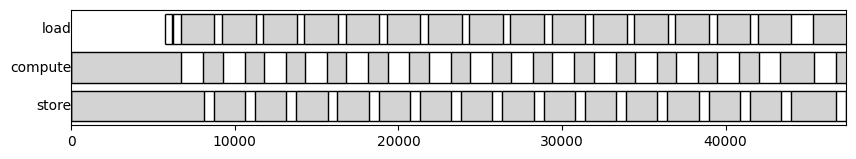

In [10]:
# Clock period -- right now hard-coded.  Should be 
# Create a timing diagram
td = TimingDiagram()

# Add a binary signal for each stage so that we can visualize when each 
# stage is active
sig_info = {}
for k in times:
    nr = times[k].shape[0]
    sig_times = times[k].ravel()
    sig_vals = []
    for i in range(nr):
        sig_vals.append(str(i))  # Start time
        sig_vals.append('x')  # End time
    sig_info[k] = SigTimingInfo(name=k, times=sig_times, values=sig_vals)
    td.add_signal(sig_info[k])


ax = td.plot_signals(text_mode='never')


